In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Times New Roman']  # 指定默认
plt.rcParams['axes.unicode_minus'] = False
# ===== 配置 =====

In [ ]:
#高效版本计算
import os
import numpy as np
import xarray as xr
from numba import njit, prange
from scipy.stats import norm

# === 设置路径 ===
data_dir = "D:/Permafrost/EN_MASK/stmi/swvl/swvl3_y.nc"
output_path = "D:/Permafrost/EN_MASK/stmi/swvl/result_3_fast.nc"

# === 读取数据 ===
ds = xr.open_dataset(data_dir)['swvl3'].values  # shape: (time, lat, lon)
years = list(range(1997, 2022))
n_years = len(years)
nlat, nlon = ds.shape[1], ds.shape[2]

# === 定义Numba加速的函数 ===
@njit
def mann_kendall_sen(x):
    n = len(x)
    S = 0
    count = 0
    for j in range(1, n):
        for k in range(j):
            if x[j] > x[k]:
                S += 1
            elif x[j] < x[k]:
                S -= 1
            count += 1

    VAR_S = n * (n - 1) * (2 * n + 5) / 18
    if S > 0:
        Z = (S - 1) / np.sqrt(VAR_S)
    elif S < 0:
        Z = (S + 1) / np.sqrt(VAR_S)
    else:
        Z = 0.0

    # Sen's slope计算（避免combinations）
    slopes = []
    for i in range(n - 1):
        for j in range(i + 1, n):
            slopes.append((x[j] - x[i]) / (j - i))
    sen = np.median(np.array(slopes))

    return Z, sen

@njit(parallel=True)
def calc_trend(data, n_years):
    nlat, nlon = data.shape[1], data.shape[2]
    trend = np.full((nlat, nlon), np.nan)
    sen_nc = np.full((nlat, nlon), np.nan)
    for i in prange(nlat):
        for j in range(nlon):
            x = data[:, i, j]
            if np.any(np.isnan(x)) or np.all(x <= 0):
                continue
            Z, sen = mann_kendall_sen(x)
            sen_nc[i, j] = sen
            absZ = abs(Z)
            if absZ >= 2.58 and sen > 0.0005:
                trend[i, j] = 3
            elif 1.96 <= absZ < 2.58 and sen > 0.0005:
                trend[i, j] = 2
            elif 1.645 <= absZ < 1.96 and sen > 0.0005:
                trend[i, j] = 1
            elif absZ < 1.645 or abs(sen) < 0.0005:
                trend[i, j] = 0
            elif absZ >= 2.58 and sen < -0.0005:
                trend[i, j] = -3
            elif 1.96 <= absZ < 2.58 and sen < -0.0005:
                trend[i, j] = -2
            elif 1.645 <= absZ < 1.96 and sen < -0.0005:
                trend[i, j] = -1
    return trend, sen_nc

# === 主计算 ===
print("开始计算趋势分类...")
trend_result, sen_result = calc_trend(ds, n_years)
print("计算完成，正在保存...")

# === 保存为 NetCDF ===
lat = xr.open_dataset(data_dir).coords['latitude']
lon = xr.open_dataset(data_dir).coords['longitude']
trend_ds = xr.Dataset({'trend': (['latitude', 'longitude'], trend_result)},
                      coords={'latitude': lat, 'longitude': lon})
sen_ds = xr.Dataset({'sen': (['latitude', 'longitude'], sen_result)},
                      coords={'latitude': lat, 'longitude': lon})
sen_ds.to_netcdf(output_path.replace("result", "sen"))
trend_ds.to_netcdf(output_path)
print("✅ 已完成趋势计算并保存至：", output_path)

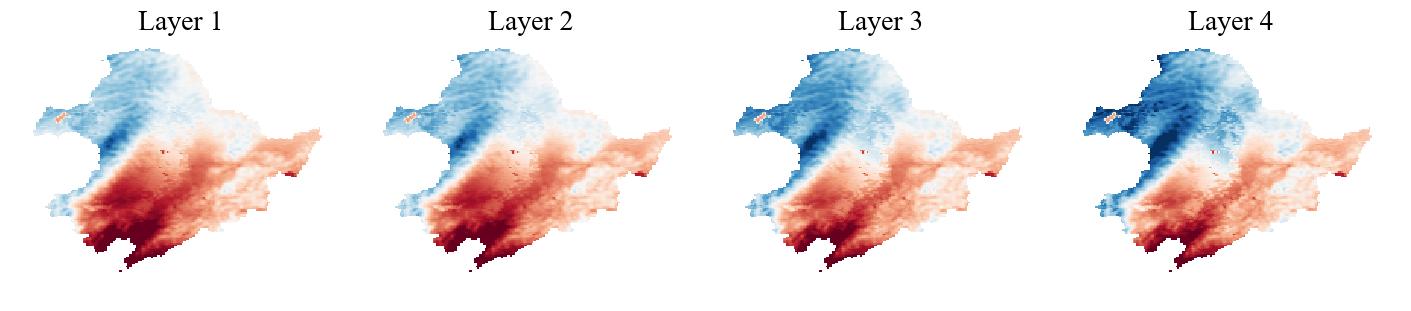

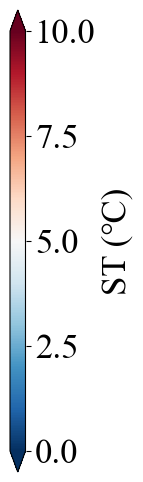

In [20]:
# 空间绘制 四层基线年
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# 1. 读取NC文件
did = 0
if did==0:
    data1 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl1_y.nc")['stl1'][0] - 273.15
    data2 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl2_y.nc")['stl2'][0] - 273.15
    data3 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl3_y.nc")['stl3'][0] - 273.15
    data4 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl4_y.nc")['stl4'][0] - 273.15
else:
    data1 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl1_y.nc")['swvl1'][0]
    data2 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl2_y.nc")['swvl2'][0]
    data3 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl3_y.nc")['swvl3'][0]
    data4 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl4_y.nc")['swvl4'][0]
# 创建一个图形
fig, axe = plt.subplots(1,4, figsize=(14, 3), constrained_layout=True)
if did==0:norm = mpl.colors.Normalize(vmin=0, vmax=10)
else:norm = mpl.colors.Normalize(vmin=0, vmax=0.5)
# 绘制图像
for i,pl in enumerate([data1, data2, data3, data4]):
    if did==0:im = pl.plot.imshow(ax=axe[i], cmap='RdBu_r', norm=norm, add_colorbar=False)   #RdBu_r
    else: im = pl.plot.imshow(ax=axe[i], cmap='Blues', norm=norm, add_colorbar=False)   #RdBu_r
    # 保留边框但隐藏刻度和标签
    axe[i].tick_params(axis='both', which='both', length=0)
    axe[i].set_title('Layer ' + str(i+1), fontsize=20)
    for s in ['top', 'right', 'bottom', 'left']:
        axe[i].spines[s].set_visible(False)
    axe[i].set_xticks([])
    axe[i].set_yticks([])
    axe[i].set_xlabel('')
    axe[i].set_ylabel('')
plt.show()
fig_cb, ax_cb = plt.subplots(figsize=(0.2, 6))
if did==0:sm = mpl.cm.ScalarMappable(norm=norm, cmap='RdBu_r')
else:sm = mpl.cm.ScalarMappable(norm=norm, cmap='Blues')
sm.set_array([])  # 必须有
cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical', extend='both')
if did == 0:
    cbar.set_label('ST (℃)', fontsize=25)
    ticks = np.linspace(0, 10, 5)
else:
    cbar.set_label('SM (m³/m³)', fontsize=25)
    ticks = np.linspace(0, 0.5, 5)
cbar.ax.tick_params(labelsize=25)
cbar.set_ticks(ticks)
plt.show()

In [ ]:
# 空间绘制  trend
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
# 1. 读取NC文件
# td1 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/result_1_fast.nc")['trend']
# td2 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/result_2_fast.nc")['trend']
# td3 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/result_3_fast.nc")['trend']
# td4 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/result_4_fast.nc")['trend']
td1 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/result_1_fast.nc")['trend']
td2 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/result_2_fast.nc")['trend']
td3 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/result_3_fast.nc")['trend']
td4 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/result_4_fast.nc")['trend']
# 创建一个图形
bounds = [-3,-2,-1,1,2,3]  # '#333C98', '#659BC8', "#E6E5E5FF", '#EB5A3A', '#AC0726'
colors = ['#333C98', '#659BC8', "#E6E5E5FF", '#EB5A3A', '#AC0726']  #'#555AA7','#60BBA7','#FFFFBE','#F36B43','#BD2349'    \\\\
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, ncolors=len(cmap.colors))
fig, axe = plt.subplots(1,4, figsize=(14, 3), constrained_layout=True)
# 绘制图像
for i,pl in enumerate([td1, td2, td3, td4]):
    im = pl.plot.imshow(ax=axe[i], cmap=cmap, norm=norm, add_colorbar=False)
    if i == 3:
        cbar = fig.colorbar(im, ax=axe[i], shrink=1, pad=0.05)
        cbar.set_label('The Theil-Sen change rate', fontsize=15)
        cbar.ax.tick_params(labelsize=15)
    # 保留边框但隐藏刻度和标签
    axe[i].tick_params(axis='both', which='both', length=0)
    for s in ['top', 'right', 'bottom', 'left']:
        axe.spines[s].set_visible(False)
    axe[i].set_xticks([])
    axe[i].set_yticks([])
    axe[i].set_xlabel('')
    axe[i].set_ylabel('')
    axe[i].set_title('')
plt.show()
td1.close(), td2.close(), td3.close(), td4.close()

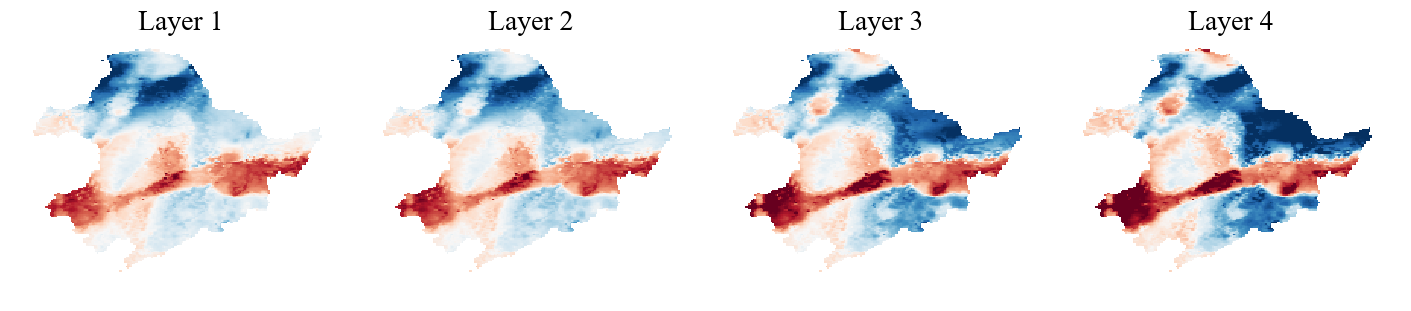

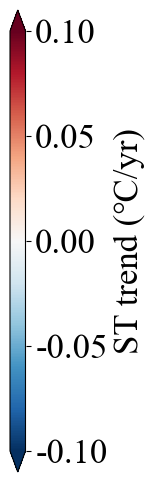

In [3]:
# 空间绘制 四层平均年际变化
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# 1. 读取NC文件
did = 0
if did == 0:
    data1 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl1_y.nc")['stl1'] - 273.15
    data2 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl2_y.nc")['stl2'] - 273.15
    data3 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl3_y.nc")['stl3'] - 273.15
    data4 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/stl/stl4_y.nc")['stl4'] - 273.15
else:
    data1 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl1_y.nc")['swvl1']
    data2 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl2_y.nc")['swvl2']
    data3 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl3_y.nc")['swvl3']
    data4 = xr.open_dataset("D:/Permafrost/EN_MASK/stmi/swvl/swvl4_y.nc")['swvl4']
# 创建一个图形
fig, axe = plt.subplots(1,4, figsize=(14, 3), constrained_layout=True)
if did==0:norm = mpl.colors.Normalize(vmin=-0.1, vmax=0.1)
else: norm = mpl.colors.Normalize(vmin=-0.005, vmax=0.005)
# 绘制图像
for i,pl in enumerate([data1, data2, data3, data4]):
    var_ = (pl[-1] - pl[0]) / 25
    im = var_.plot.imshow(ax=axe[i], cmap='RdBu_r', norm=norm, add_colorbar=False)   #RdBu_r
    # 保留边框但隐藏刻度和标签
    axe[i].tick_params(axis='both', which='both', length=0)
    # 取消边框
    for s in ['top', 'right', 'bottom', 'left']:
        axe[i].spines[s].set_visible(False)
    axe[i].set_xticks([])
    axe[i].set_yticks([])
    axe[i].set_xlabel('')
    axe[i].set_ylabel('')
    axe[i].set_title('Layer ' + str(i+1), fontsize=20)
plt.show()
#
fig_cb, ax_cb = plt.subplots(figsize=(0.2, 6))
sm = mpl.cm.ScalarMappable(norm=norm, cmap='RdBu_r')
sm.set_array([])  # 必须有
cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical', extend='both')
if did == 0:cbar.set_label('ST trend (℃/yr)', fontsize=25)
else:cbar.set_label('SM trend (m³/m³/yr)', fontsize=25)
cbar.ax.tick_params(labelsize=25)
ticks = np.linspace(-0.1, 0.1, 5)
cbar.set_ticks(ticks)
plt.show()